---
title: Clustering KMeans (KNIME)
---

## Hasil Penggabungan Data 1 Kelas yang Sudah Dilakukan Ekstraksi Fitur Menggunakan TSFEL

### 1. Deskripsi dan Struktur Berkas Penggabungan (Merged Dataset)

#### Latar Belakang dan Komposisi Berkas Excel

Pada tahapan Tugas 3 sebelumnya, setiap mahasiswa di kelas telah melakukan pengolahan data deret waktu kualitas udara pada area tempat tinggal masing-masing selama periode 1 tahun kalender penuh (24 Agustus 2025 s.d. 23 Agustus 2026). Tahapan tersebut mencakup pengunduhan data satelit Sentinel-5P Level-2 melalui OpenEO Copernicus, penanganan nilai kosong (*missing values*) menggunakan interpolasi linier, penanganan nilai ekstrem (*outlier*) menggunakan metode IQR dan teknik *capping*, serta ekstraksi **68 fitur statistik, temporal, dan spektral** menggunakan *library* **TSFEL** untuk empat parameter polutan utama:

1. **CO** (*Carbon Monoxide*)
2. **SO2** (*Sulphur Dioxide*)
3. **CH4** (*Methane*)
4. **NO2** (*Nitrogen Dioxide*)

Seluruh vektor fitur hasil ekstraksi dari 19 mahasiswa dalam satu kelas kemudian dikumpulkan dan digabungkan secara sistematis ke dalam satu berkas spreadsheet terpadu bernama **`data_tsfel_20260920_080900.xlsx`**. Berkas gabungan ini menjadi fondasi utama untuk melakukan analisis data tingkat lanjut, yaitu klasterisasi tanpa supervisi (*unsupervised clustering*) menggunakan algoritma **K-Means** pada platform analitik visual **KNIME**.

#### Rincian Lembar Kerja (Sheets) pada Berkas Excel

Berkas `data_tsfel_20260920_080900.xlsx` terdiri dari **5 lembar kerja (*worksheets*)** yang terorganisasi secara modular:

| No | Nama Lembar Kerja (*Sheet*) | Dimensi Data | Jumlah Fitur | Deskripsi Isi Lembar Kerja |
| :---: | :--- | :---: | :---: | :--- |
| 1 | `Semua Fitur` | 19 baris $\times$ 274 kolom | 272 fitur | Matriks gabungan seluruh fitur dari 4 polutan dengan format `<POLUTAN> - <nama_fitur>` serta 2 kolom identitas (`Nama`, `Daerah`). |
| 2 | `CO` | 19 baris $\times$ 70 kolom | 68 fitur | Kumpulan 68 fitur TSFEL khusus untuk deret waktu konsentrasi Karbon Monoksida (CO). |
| 3 | `SO2` | 19 baris $\times$ 70 kolom | 68 fitur | Kumpulan 68 fitur TSFEL khusus untuk deret waktu konsentrasi Sulfur Dioksida (SO2). |
| 4 | `CH4` | 19 baris $\times$ 70 kolom | 68 fitur | Kumpulan 68 fitur TSFEL khusus untuk deret waktu konsentrasi Metana (CH4). |
| 5 | `NO2` | 19 baris $\times$ 70 kolom | 68 fitur | Kumpulan 68 fitur TSFEL khusus untuk deret waktu konsentrasi Nitrogen Dioksida (NO2). |

Pada lembar kerja utama `Semua Fitur`, penamaan kolom menggunakan konvensi terstandarisasi `<POLUTAN> - <nama_fitur>` (misalnya `CO - abs_energy`, `SO2 - auc`, `CH4 - calc_mean`, dan `NO2 - zero_cross`), sehingga memudahkan pemilahan dan penerapan transformasi fitur saat diproses dalam *workflow* analitik.

### 2. Informasi Partisipan dan Sebaran Wilayah Pengamatan

#### Daftar Mahasiswa dan Wilayah Pengamatan (Daerah)

Dataset gabungan ini merepresentasikan keragaman kondisi atmosfer dari **19 wilayah pengamatan** yang tersebar di berbagai wilayah geografis di Indonesia, mulai dari kawasan metropolitan padat penduduk, kawasan industri penyangga, wilayah agrikultur, kawasan pesisir, kepulauan terpencil, hingga kawasan luar Pulau Jawa:

| No | Nama Mahasiswa | Wilayah Pengamatan (Daerah) | Karakteristik Wilayah |
| :---: | :--- | :--- | :--- |
| 1 | Achmad Saiful Fuadi | Labang, Bangkalan | Pesisir / Akses Jembatan Suramadu |
| 2 | Ahmad Ubaidillah Mappattiro | Masalembu | Kepulauan Terpencil di Laut Jawa |
| 3 | Ahmad soleh majid | Socah, Bangkalan | Pesisir Barat Madura |
| 4 | Aisya | Biak Kota | Kawasan Perkotaan Kepulauan Papua |
| 5 | Alif Baiatur Ridhwan El Habibie | Surabaya, Gubeng | Kawasan Urban / Perkotaan Padat |
| 6 | Firman Candra Dwi Nugroho | Kraton, Bangkalan | Pusat Kota Bangkalan |
| 7 | Intan Resti Haslindawati | Kadur, Pamekasan | Dataran Tinggi / Pedalaman Madura |
| 8 | Irwan Dwi Mukhlisin | Lamongan kota | Kawasan Perkotaan Lamongan |
| 9 | Kevin Koligombowo Mangaraja | Telukdalam, Nias | Kepulauan Nias, Sumatra Utara |
| 10 | Mohammad Andri Firmansyah | Trowulan, Mojokerto | Kawasan Agrikultur & Cagar Budaya |
| 11 | Mohammad Waqidi | Lenteng | Kawasan Rural / Pedesaan Sumenep |
| 12 | Muhammad Ainul Fuady | Gresik, Bungah | Kawasan Industri & Pesisir Utara |
| 13 | Muhammad Fathul Iman Wahid | Burneh, Bangkalan | Kawasan Penyangga Kota Bangkalan |
| 14 | Muhammad Ilham | Mendenrejo | Kawasan Pedalaman Blora / Jawa Tengah |
| 15 | Muhammad Sirul Amin | Klampis | Kawasan Pesisir Utara Madura |
| 16 | Raihan Aryanova Narendra | Sokobanah | Kawasan Pesisir Utara Sampang |
| 17 | Shofiatul Mahmudah | Guluk-Guluk, Sumenep | Kawasan Pesantren / Perbukitan Madura |
| 18 | Wildan Haydar Amru (Penulis) | Krian, Sidoarjo | Kawasan Industri & Penyangga Metropolitan |
| 19 | fikri mutawakkil | Pakong, Pamekasan | Kawasan Pedalaman Tengah Madura |

Penulis sendiri berada pada nomor urut ke-18 (**Wildan Haydar Amru**) dengan wilayah pengamatan di **Kecamatan Krian, Kabupaten Sidoarjo**, yang merupakan kawasan industri padat dan jalur logistik penghubung utama di Jawa Timur. Keanekaragaman tipe wilayah ini sangat ideal untuk diuji menggunakan algoritma pengelompokan (*clustering*), karena setiap tipe wilayah memiliki sidik jari polutan yang unik akibat pengaruh aktivitas antropogenik dan kondisi geografis lokal.

### 3. Eksplorasi dan Verifikasi Kualitas Data Menggunakan Python

#### Pemuatan dan Pemeriksaan Struktur Dataset Gabungan

Kita memuat lembar kerja `Semua Fitur` dari berkas `data_tsfel_20260920_080900.xlsx` menggunakan *library* Pandas untuk memeriksa dimensi tabel, nama-nama kolom, serta struktur 5 baris pertama dataset gabungan kelas.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Memuat lembar kerja utama 'Semua Fitur' dari berkas Excel gabungan kelas
excel_path = 'data_tsfel_20260920_080900.xlsx'
df_all = pd.read_excel(excel_path, sheet_name='Semua Fitur')

print(f"Ukuran dataset gabungan: {df_all.shape[0]} baris (mahasiswa/wilayah) x {df_all.shape[1]} kolom")
df_all.head()

Ukuran dataset gabungan: 19 baris (mahasiswa/wilayah) x 274 kolom


,Nama,Daerah,CO - abs_energy,CO - auc,CO - autocorr,CO - average_power,CO - calc_centroid,CO - calc_max,CO - calc_mean,CO - calc_median,...,NO2 - spectral_spread,NO2 - spectral_variation,NO2 - spectrogram_mean_coeff,NO2 - sum_abs_diff,NO2 - wavelet_abs_mean,NO2 - wavelet_energy,NO2 - wavelet_entropy,NO2 - wavelet_std,NO2 - wavelet_var,NO2 - zero_cross
0,Achmad Saiful Fuadi,"Labang,Bangkalan",0.307011,10.503863,3.0,0.000841,179.624253,0.037147,0.028791,0.028945,...,0.147387,0.235198,3.140000e-09,0.002857,3.371854e-05,0.000034,2.141037,0.000034,3.371854e-05,14.0
1,Ahmad Ubaidillah Mappattiro,Masalembu,0.295187,10.295264,4.0,0.000811,177.872341,0.036090,0.028285,0.028129,...,0.158121,0.447199,3.352650e-10,0.001137,2.824478e-08,0.000003,0.000000,0.000003,1.121645e-11,22.0
2,Ahmad soleh majid,"Socah,Bangkalan",0.300680,0.104004,2.0,0.082604,1.816485,0.036134,0.028584,0.028389,...,14.365708,0.387386,2.830000e-12,0.002006,1.410000e-06,0.000021,2.115042,0.000021,5.000000e-10,0.0
3,Aisya,Biak Kota,0.221284,8.853567,4.0,0.000608,182.956589,0.052832,0.024358,0.024713,...,14.110228,0.235286,2.588241e-13,0.000836,1.117762e-07,0.000005,2.177652,0.000005,2.972559e-11,68.0
4,Alif Baiatur Ridhwan El Habibie,"Surabaya, Gubeng",0.302971,10.408313,2.0,0.000832,182.253150,0.036863,0.028604,0.028693,...,0.142730,0.242086,2.783743e-09,0.002689,9.359024e-08,0.000009,0.000000,0.000009,8.217608e-11,0.0


#### Verifikasi Missing Values dan Distribusi Kolom Fitur

Integritas data merupakan prasyarat mutlak sebelum data dimasukkan ke dalam algoritma klasterisasi berbasis jarak seperti K-Means. Kita melakukan verifikasi ketiadaan nilai kosong (*missing values*) serta menghitung sebaran jumlah kolom fitur untuk masing-masing polutan.

In [5]:
# Verifikasi jumlah nilai kosong (null/NaN) di seluruh tabel
total_null = df_all.isnull().sum().sum()
print(f"Total Missing Values pada dataset gabungan: {total_null}")

# Pengelompokan kolom berdasarkan polutan
id_cols = ['Nama', 'Daerah']
co_cols = [c for c in df_all.columns if c.startswith('CO - ')]
so2_cols = [c for c in df_all.columns if c.startswith('SO2 - ')]
ch4_cols = [c for c in df_all.columns if c.startswith('CH4 - ')]
no2_cols = [c for c in df_all.columns if c.startswith('NO2 - ')]

ringkasan_kolom = pd.DataFrame({
    'Kelompok Kolom': ['Identitas (Nama & Daerah)', 'Fitur Polutan CO', 'Fitur Polutan SO2', 'Fitur Polutan CH4', 'Fitur Polutan NO2', 'Total Kolom Fitur TSFEL'],
    'Jumlah Kolom': [len(id_cols), len(co_cols), len(so2_cols), len(ch4_cols), len(no2_cols), len(co_cols) + len(so2_cols) + len(ch4_cols) + len(no2_cols)],
    'Persentase terhadap Total Kolom (%)': [
        round(len(id_cols) / len(df_all.columns) * 100, 2),
        round(len(co_cols) / len(df_all.columns) * 100, 2),
        round(len(so2_cols) / len(df_all.columns) * 100, 2),
        round(len(ch4_cols) / len(df_all.columns) * 100, 2),
        round(len(no2_cols) / len(df_all.columns) * 100, 2),
        round((len(co_cols) + len(so2_cols) + len(ch4_cols) + len(no2_cols)) / len(df_all.columns) * 100, 2)
    ]
})
ringkasan_kolom

Total Missing Values pada dataset gabungan: 0


,Kelompok Kolom,Jumlah Kolom,Persentase terhadap Total Kolom (%)
0,Identitas (Nama & Daerah),2,0.73
1,Fitur Polutan CO,68,24.82
2,Fitur Polutan SO2,68,24.82
3,Fitur Polutan CH4,68,24.82
4,Fitur Polutan NO2,68,24.82
5,Total Kolom Fitur TSFEL,272,99.27


#### Analisis Variasi Skala Nilai Fitur Lintas Polutan

Setiap parameter gas polutan di atmosfer memiliki satuan dan besaran konsentrasi alami yang sangat berbeda:

- **CH4** memiliki skala magnitudo ribuan (orde $10^3$ ppb).
- **CO** berada pada rentang desimal puluhan hingga ratusan ($10^{-2}$ mol/m²).
- **SO2** dan **NO2** berada pada orde pecahan mikro yang sangat kecil ($10^{-5}$ hingga $10^{-4}$ mol/m²).

Perbedaan skala magnitudo hingga 7–8 orde ini tercermin secara langsung pada nilai fitur TSFEL yang dihasilkan (misalnya nilai `calc_mean` dan `calc_std`). Hal ini membuktikan secara empiris bahwa proses **normalisasi fitur (*Z-Score Standardizer* / *Min-Max Normalizer*)** sangat krusial diterapkan sebelum pemodelan K-Means di KNIME, agar jarak antartitik tidak didominasi secara sepihak oleh fitur CH4 semata.

In [6]:
# Memeriksa statistik deskriptif untuk fitur rata-rata (calc_mean) dan standar deviasi (calc_std) per polutan
fitur_sampel = [
    'CO - calc_mean', 'SO2 - calc_mean', 'CH4 - calc_mean', 'NO2 - calc_mean',
    'CO - calc_std', 'SO2 - calc_std', 'CH4 - calc_std', 'NO2 - calc_std'
]
df_all[fitur_sampel].describe().round(6)

,CO - calc_mean,SO2 - calc_mean,CH4 - calc_mean,NO2 - calc_mean,CO - calc_std,SO2 - calc_std,CH4 - calc_std,NO2 - calc_std
count,19.000000,1.900000e+01,19.000000,1.900000e+01,19.000000,19.000000,19.000000,1.900000e+01
mean,46.129562,2.442105e+10,1345.044390,1.436842e+09,0.002959,0.000964,21.253521,4.221053e+08
std,109.382413,1.064489e+11,816.290168,6.263050e+09,0.000537,0.001217,50.929385,1.839914e+09
min,0.024358,-1.500000e-05,0.086300,2.000000e-06,0.001504,0.000054,0.000000,4.000000e-06
25%,0.028594,3.400000e-05,292.000000,1.800000e-05,0.002691,0.000170,0.005615,9.000000e-06
50%,0.028793,5.500000e-05,1868.581734,3.800000e-05,0.002825,0.000202,11.577940,1.700000e-05
75%,0.030135,1.460103e+02,1892.651922,3.653067e+01,0.003351,0.002638,16.685879,2.732000e-03
max,292.000000,4.640000e+11,1904.645148,2.730000e+10,0.003728,0.002740,228.831329,8.020000e+09


### 4. Kesiapan Dataset untuk Analisis Klasterisasi K-Means di KNIME

#### Peran Dataset dalam Alur Kerja Analitik Lanjutan

Berdasarkan hasil eksplorasi di atas, dataset `data_tsfel_20260920_080900.xlsx` telah berada dalam kondisi siap pakai (*clean, consistent, and structured*) untuk dianalisis pada bab berikutnya menggunakan **KNIME Analytics Platform**.

Rencana alur kerja pemrosesan data di KNIME meliputi:

1. **Pemuatan Berkas (*Excel Reader*)**: Membaca sheet `Semua Fitur` dari berkas `data_tsfel_20260920_080900.xlsx` ke dalam memori kerja KNIME.
2. **Prapemrosesan & Normalisasi (*Normalizer*)**: Menstandardisasi seluruh 272 kolom fitur numerik menggunakan metode Z-Score (*StandardScaler*) atau Min-Max Normalization agar seluruh fitur berbobot setara.
3. **Reduksi Dimensi (*Principal Component Analysis / PCA*)**: Mengurangi dimensionalitas tinggi (272 fitur) menjadi sejumlah komponen utama (*principal components*) untuk mengatasi fenomena *curse of dimensionality* (jumlah fitur $p = 272$ jauh melampaui jumlah observasi $n = 19$).
4. **Klasterisasi K-Means (*k-Means Node*)**: Mengelompokkan ke-19 mahasiswa/wilayah ke dalam $k$ klaster optimal berdasarkan kemiripan pola atmosferik.
5. **Visualisasi Interaktif (*Table View & Scatter Plot*)**: Memvisualisasikan sebaran klaster wilayah dan menganalisis karakteristik polutan dari setiap kelompok wilayah yang terbentuk.

## Clustering K-Means Menggunakan KNIME

### Membuka KNIME & Membuat Workspace Baru

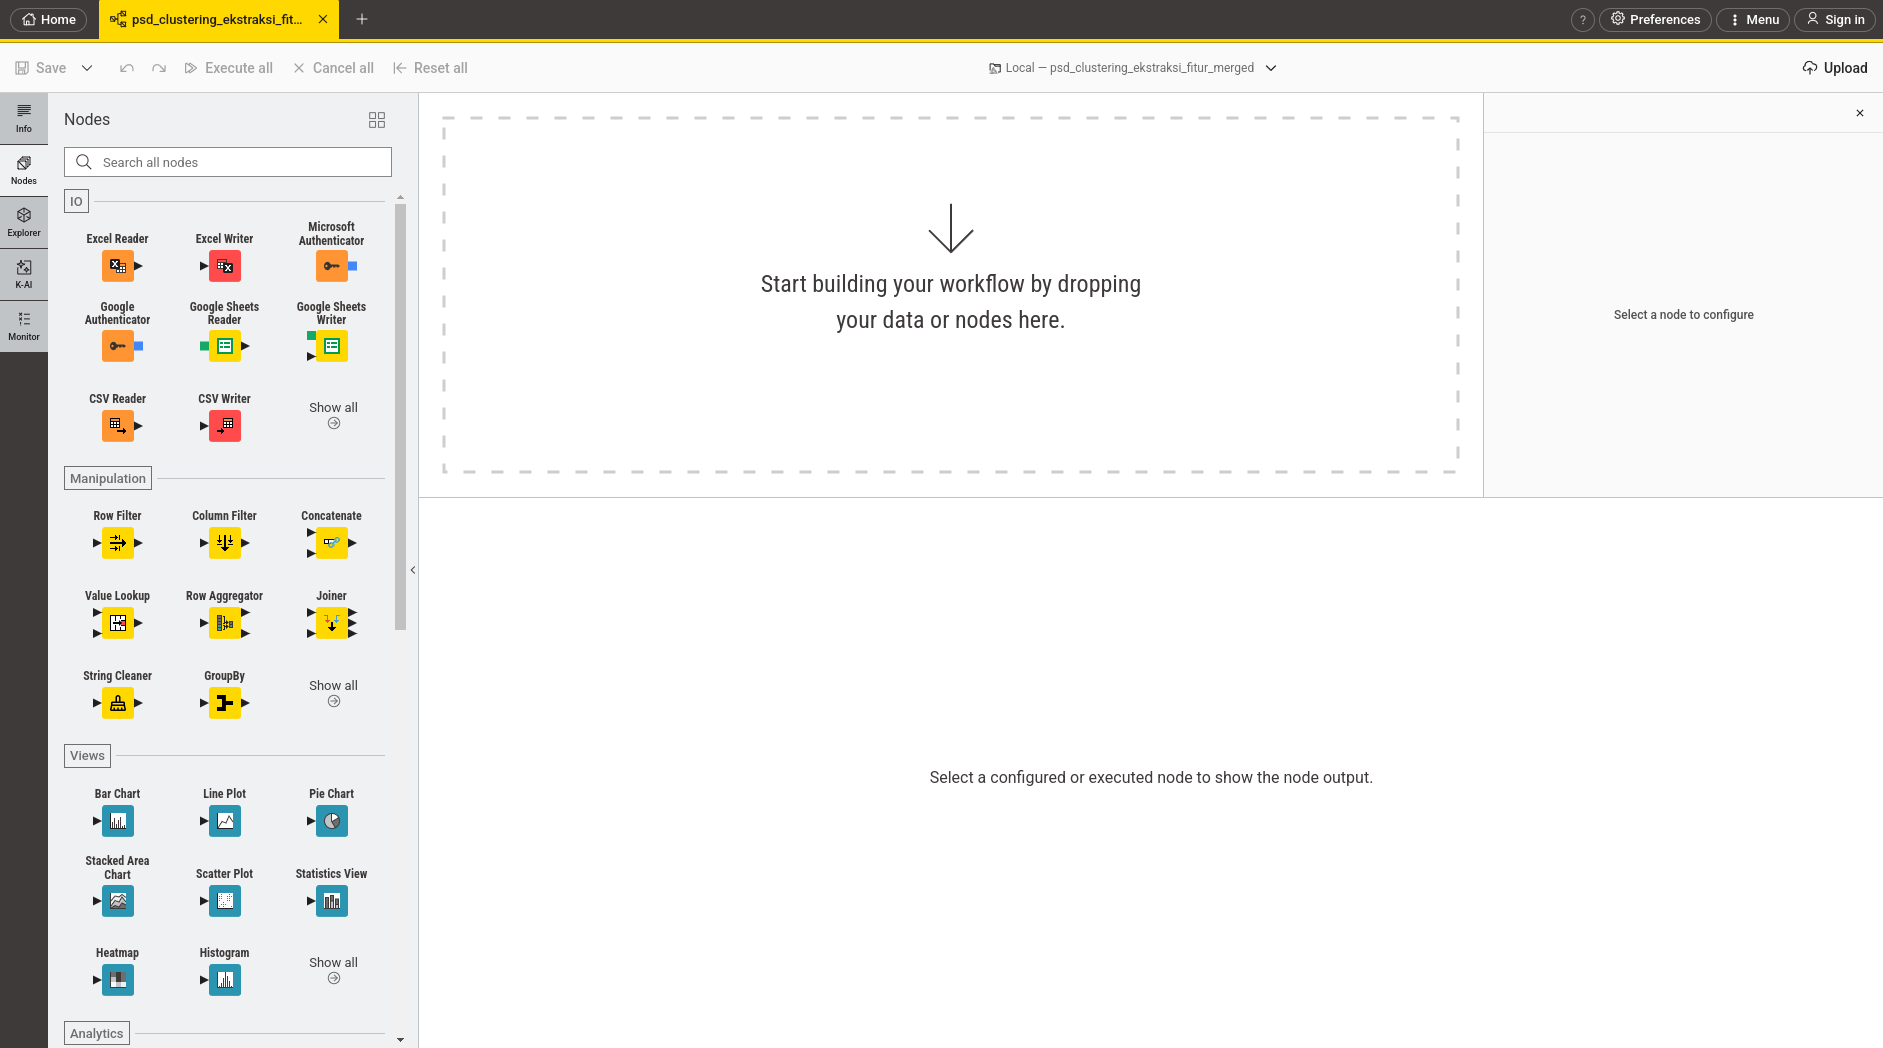

### Membaca File Excel (Dataset) Menggunakan Node "_Excel Reader_"

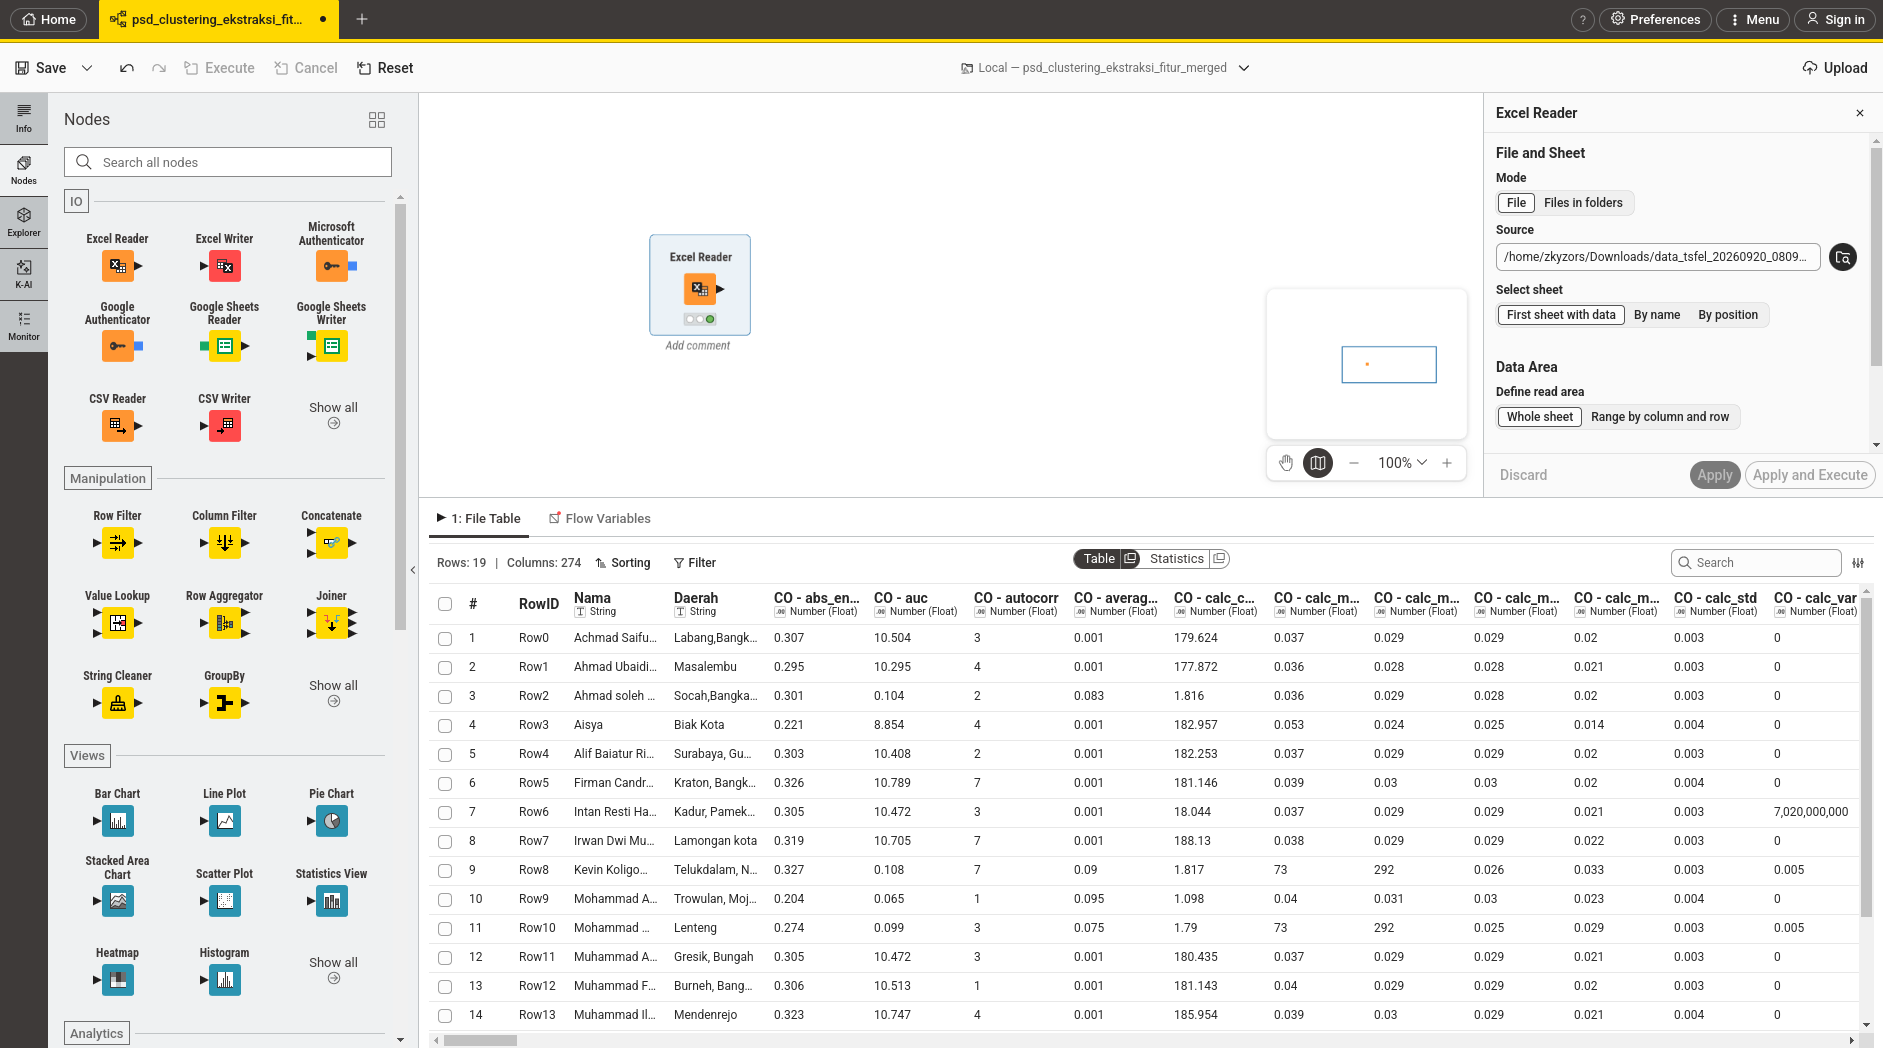

### Melakukan K-Means Menggunakan Node "K-Means" (Tanpa PCA)

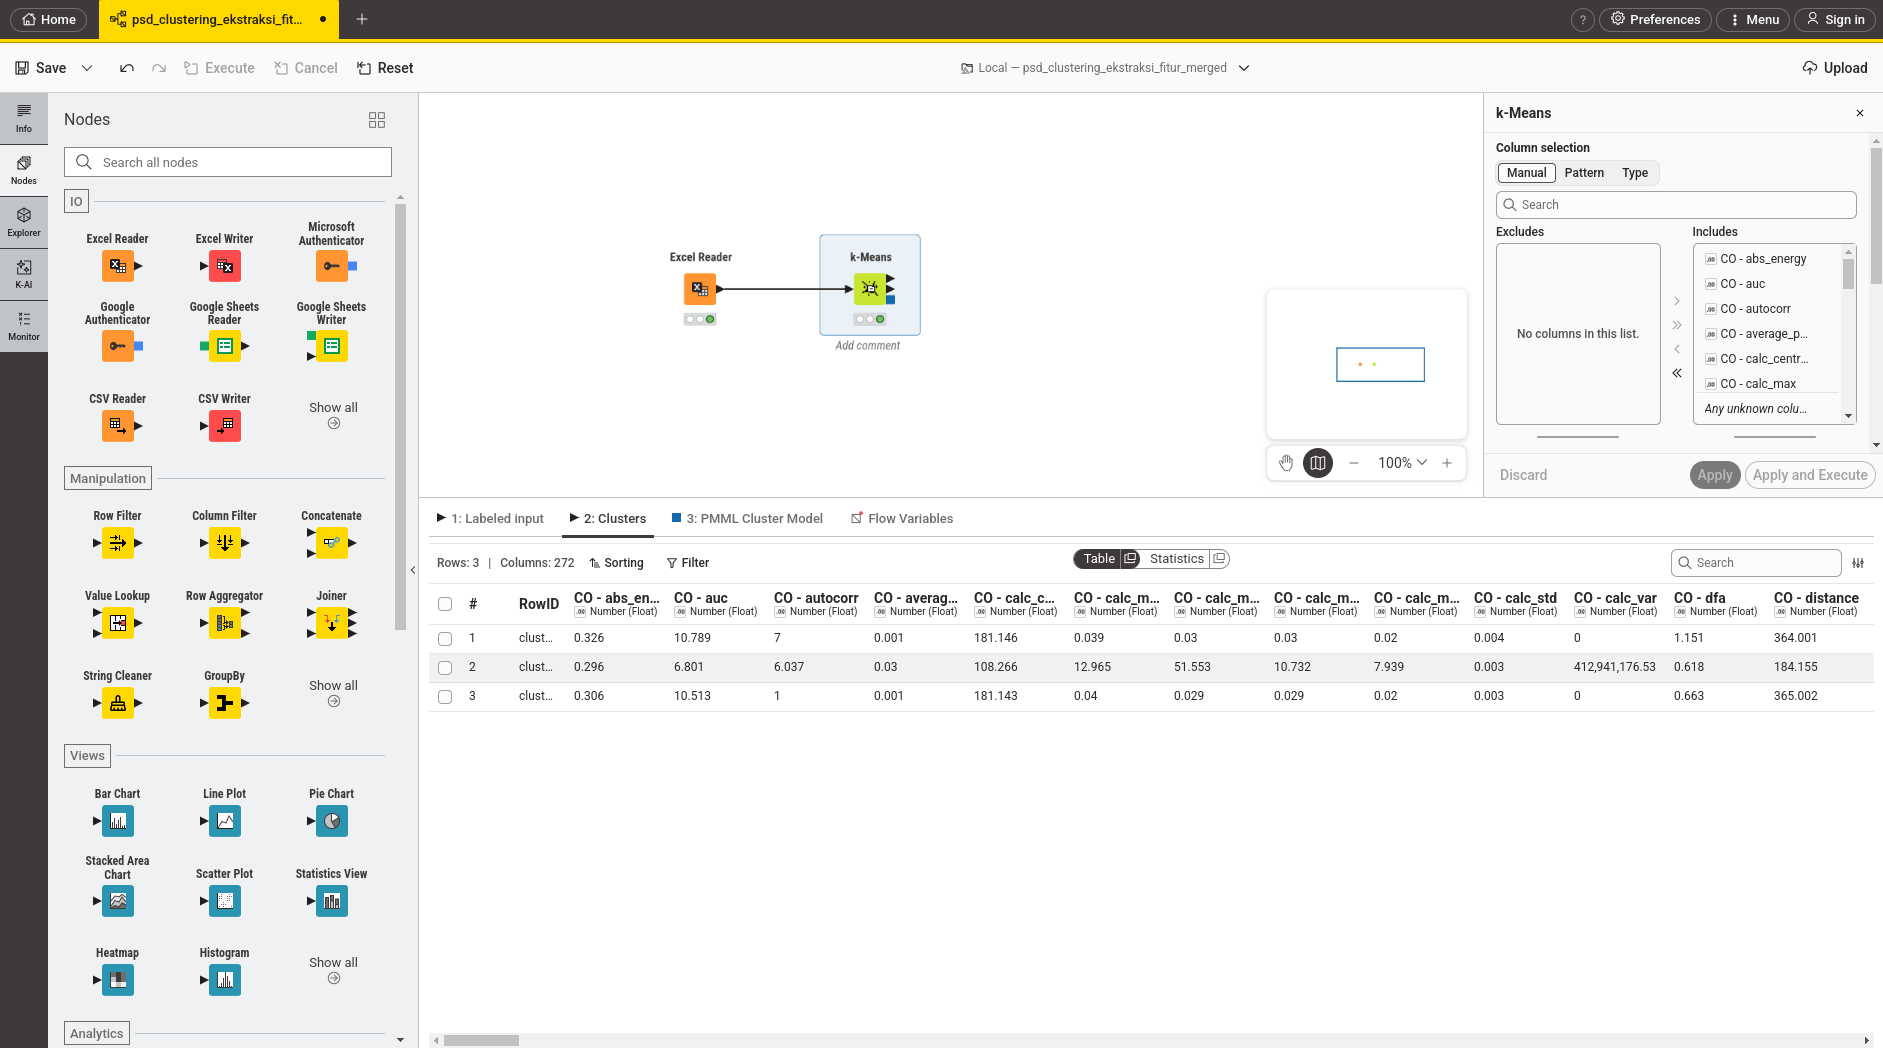

### Melakukan K-Means Menggunakan Node "K-Means" (Dengan PCA)

#### Menambahkan Node PCA Terlebih Dahulu (Diatur 19, Karena Ada 19 Mahasiswa)

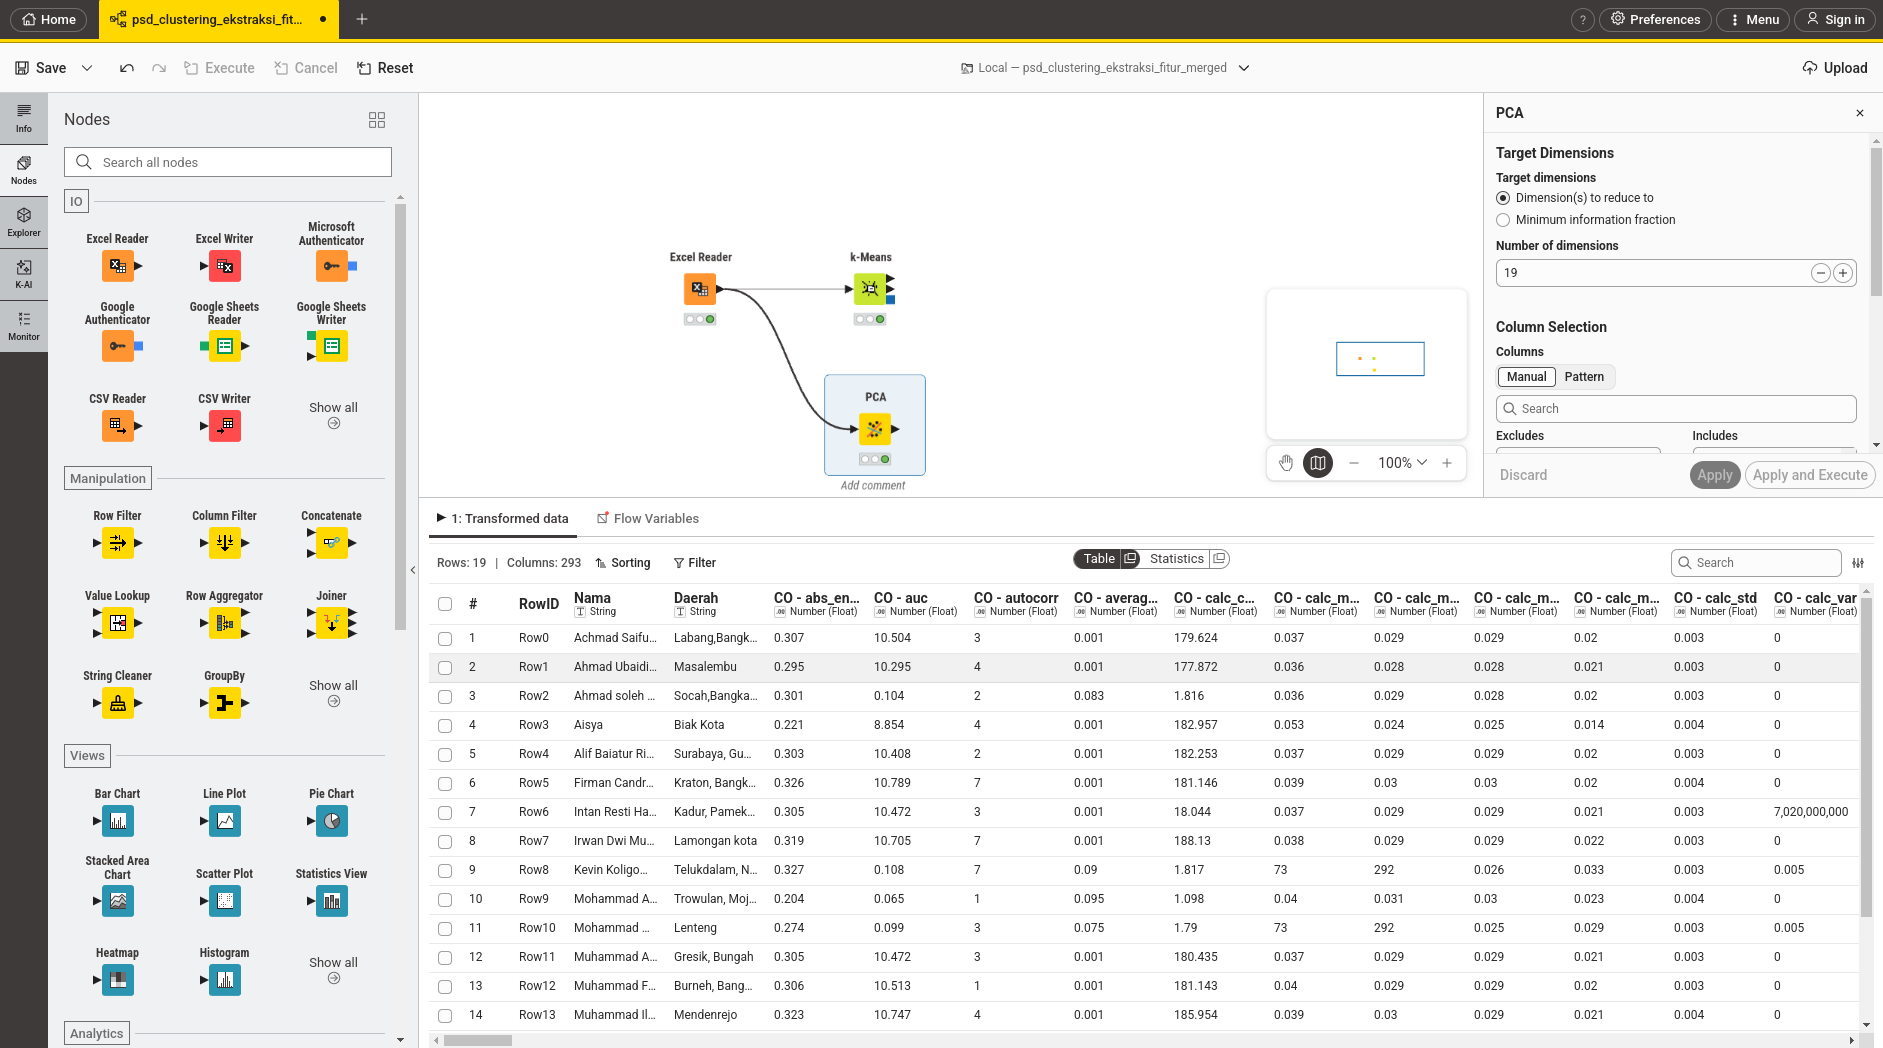

#### Menambahkan Node K-Means Setelah Node PCA

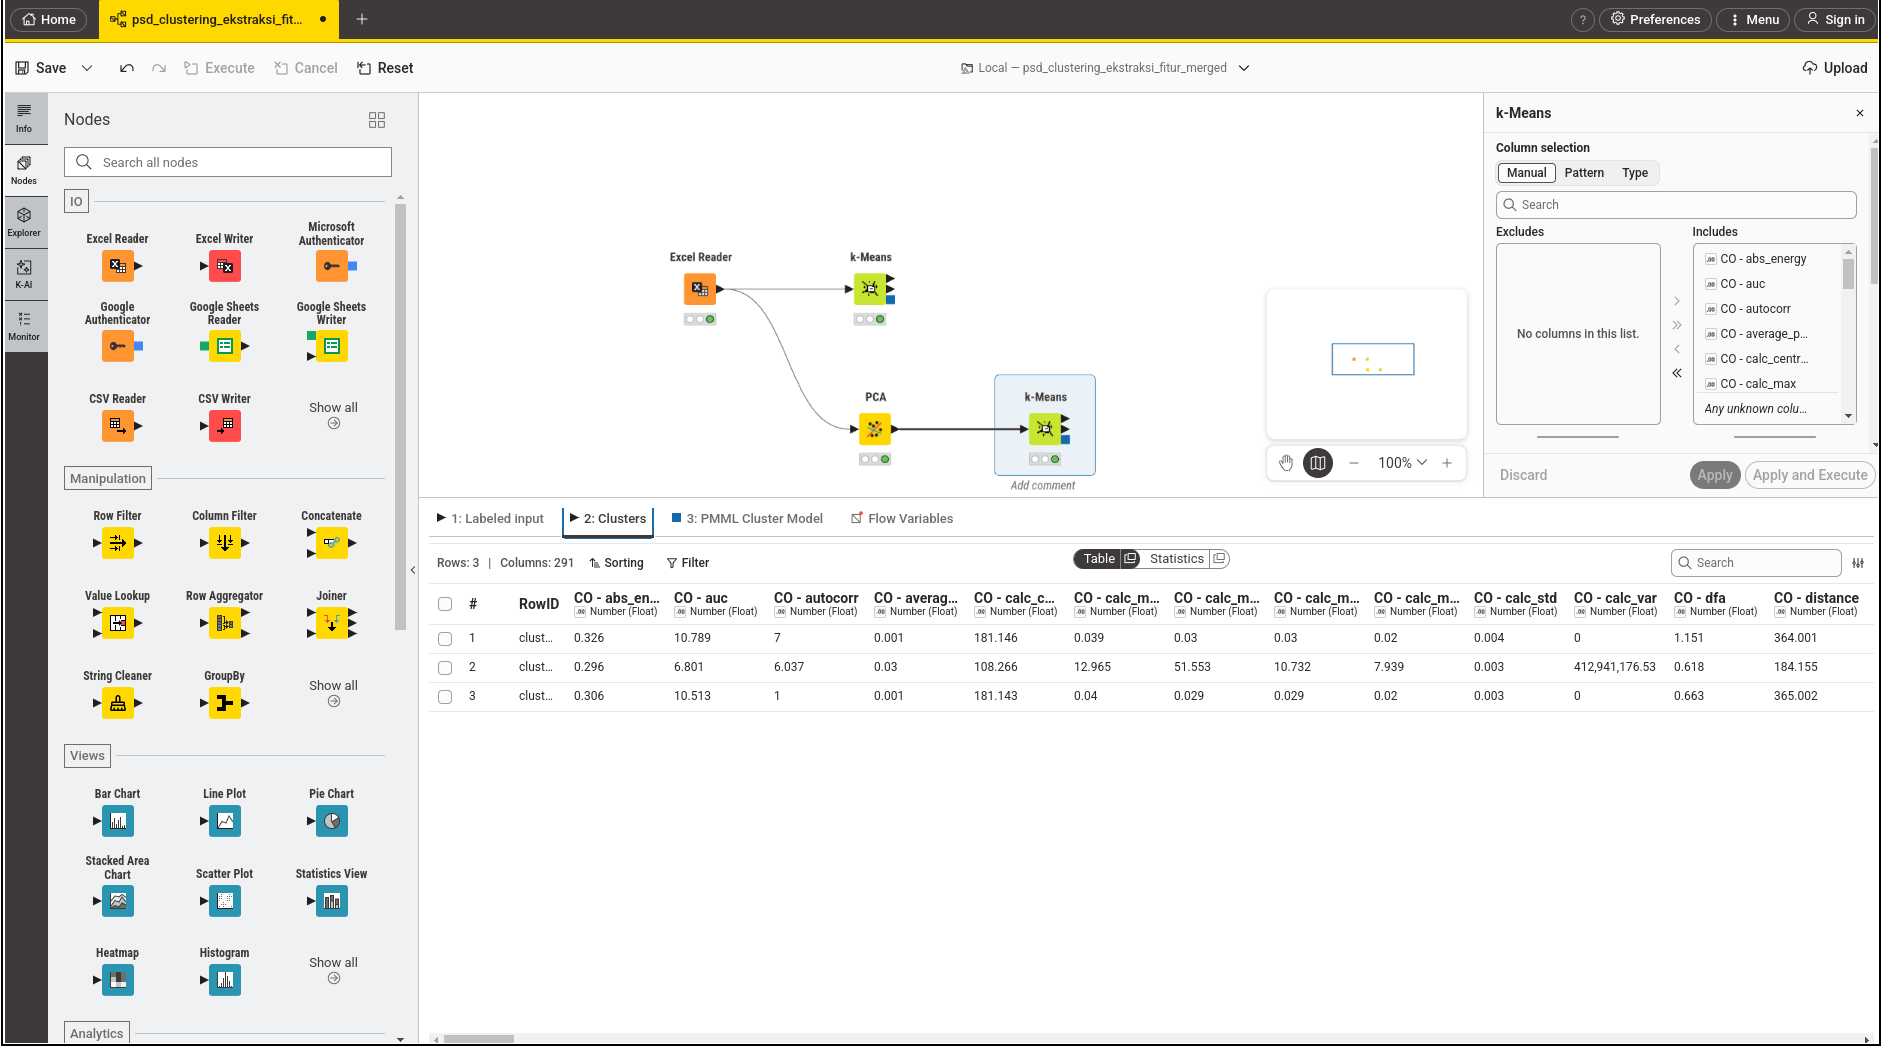

### Menambahkan Table View untuk Melihat isi Tabel

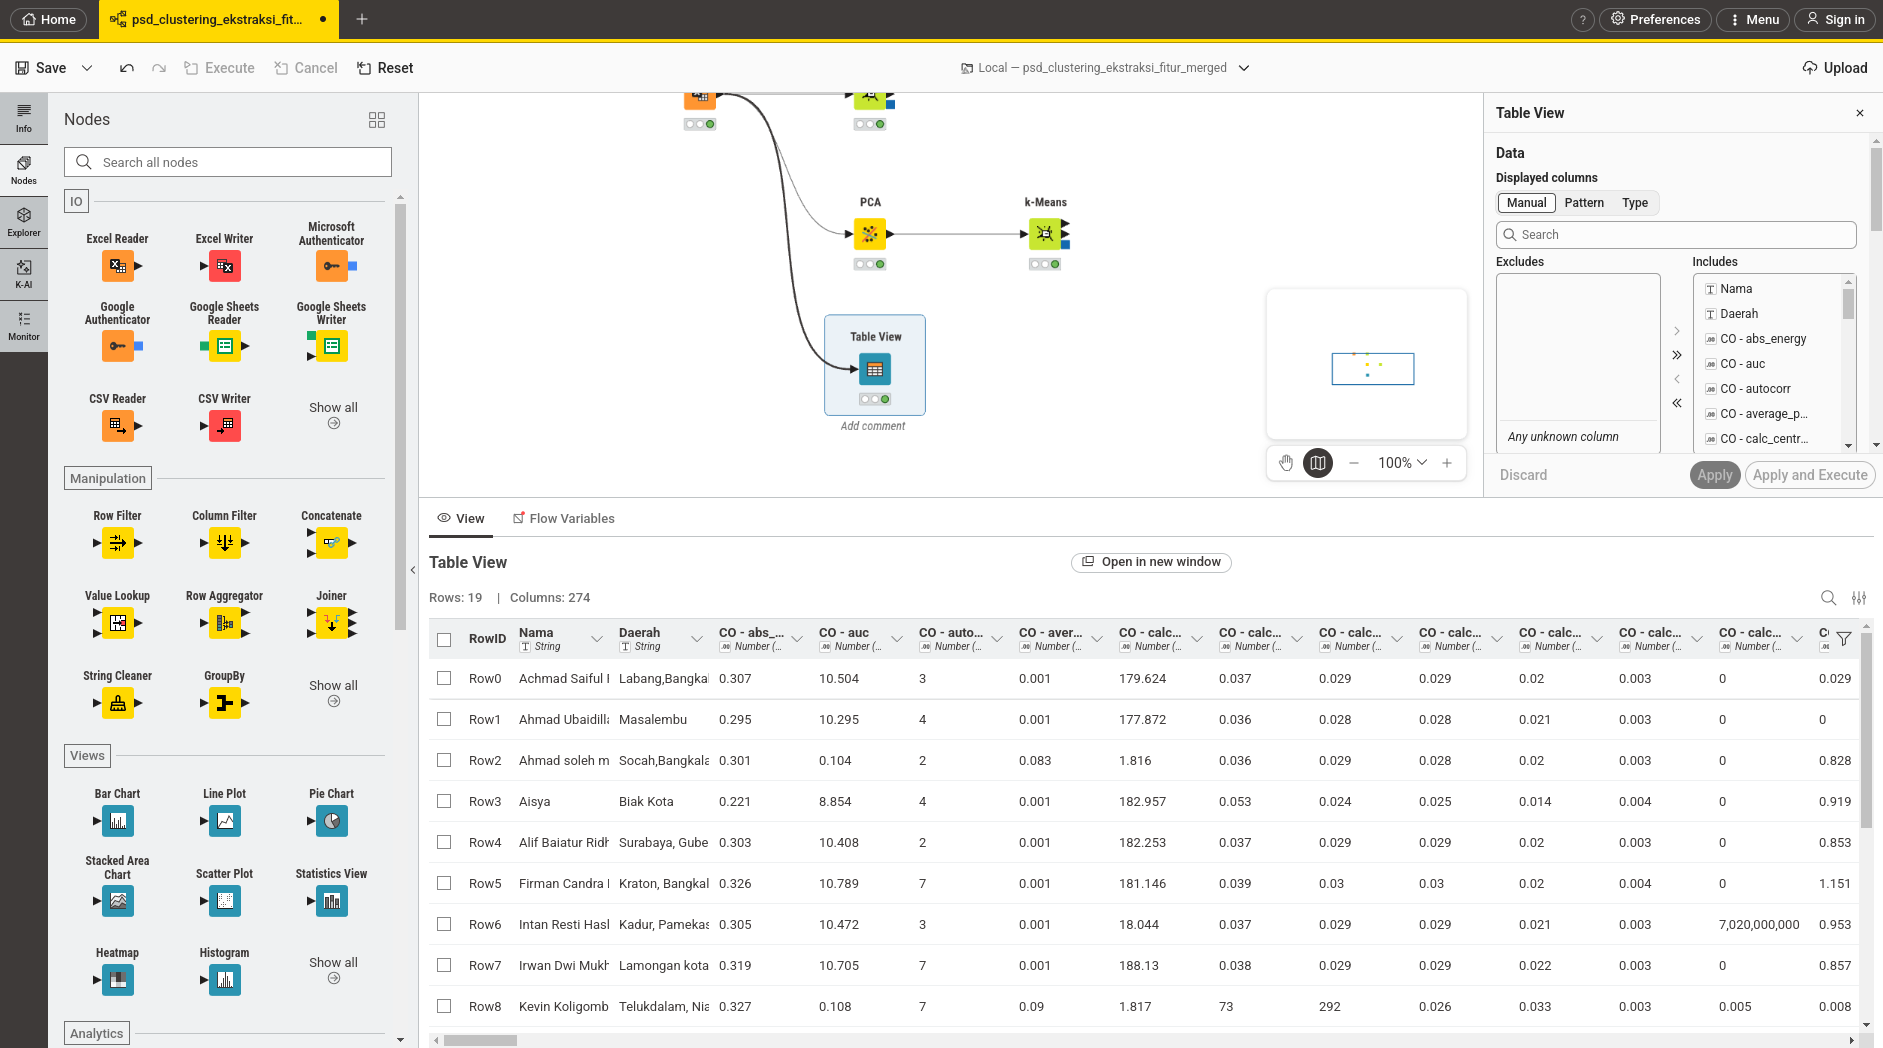